# PDF converting with olmOCR model and OpenVINO

<div class="alert alert-block alert-danger"> <b>Important note:</b> This notebook requires python >= 3.11. Please make sure that your environment fulfill to this requirement before running it </div>


PDF documents offer a vast source of high-quality tokens for training language models, but their diverse formats and layouts present challenges for content extraction. olmOCR is introduced as an open-source Python toolkit that processes PDFs into clean, linearized plain text while preserving structured content like sections, tables, lists, and equations. The toolkit utilizes a fine-tuned 7B vision language model trained on a diverse sample of 260,000 pages from over 100,000 PDFs. olmOCR is optimized for large-scale batch processing and includes all components such as VLM weights, data, training code, and inference code.

**Model Capabilities**:
* olmOCR is capable of processing a diversity of document types, covering different domains as well as visual layouts. It uses Markdown to represent structured content, such as sections, lists, equations and tables.
* olmOCR uses both text and visual information to obtain an accurate text representation of a documents. The authors develop document-anchoring, a technique to extract text and layout information from born-digital PDF documents. document-anchoring can be used to prompt VLMs alongside images of document pages to significantly improve extraction
* To build olmOCR, the authors curate olmOCR-mix-0225, a dataset of nearly 260,000 PDF pages from a diverse set of PDFs crawled from the web and public domain books. This corpus is used to fine-tune olmOCR-7B-0225-preview from Qwen2-VL-7B-Instruct. olmOCR-mix-0225 is released to facilitate further research in document extraction, and open source model weights and code as part of the toolkit.


![image](https://github.com/user-attachments/assets/2bc83cd4-894f-464f-8fd6-0ac9c9105c80)


More details about model can be found in [model card](https://huggingface.co/allenai/olmOCR-7B-0225-preview), [paper](https://olmocr.allenai.org/papers/olmocr.pdf) and original [repo](https://github.com/allenai/olmocr).

In this tutorial we consider how to convert and optimize olmOCR model using [Optimum Intel](https://github.com/huggingface/optimum-intel). Additionally, we demonstrate how to apply model optimization techniques like weights compression using [NNCF](https://github.com/openvinotoolkit/nncf).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [The original model inference](#The-original-model-inference)
- [Convert and Optimize model](#Convert-and-Optimize-model)
    - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
- [Prepare OpenVINO GenAI Inference Pipeline](#Prepare-OpenVINO-GenAI-Inference-Pipeline)
    - [Select inference device](#Select-inference-device)
    - [Load OpenVINO model](#Load-OpenVINO-model)
- [Run OpenVINO GenAI model inference](#Run-OpenVINO-GenAI-model-inference)
- [Interactive Demo](#Interactive-Demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/olmocr-pdf-vlm/olmocr-pdf-vlm.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import platform
from pathlib import Path
import requests


if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py")
    open("pip_helper.py", "w").write(r.text)


from pip_helper import pip_install


pip_install(
    "-qU",
    "--pre",
    "openvino>=2025.0.0",
    "openvino-tokenizers>=2025.0.0",
    "openvino-genai>=2025.0.0",
    "nncf>=2.15.0",
    "--extra-index-url",
    "https://storage.openvinotoolkit.org/simple/wheels/nightly",
)
pip_install("-q", "git+https://github.com/huggingface/optimum-intel.git", "--extra-index-url", "https://download.pytorch.org/whl/cpu")
pip_install(
    "-q",
    "gradio>=4.36",
    "transformers>=4.46.2",
    "torch>=2.1",
    "tokenizers<0.21,>=0.20",
    "huggingface-hub",
    "ftfy",
    "pypdfium2",
    "pypdf>=5.2.0",
    "lingua-language-detector",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install(
    "-q", "--no-deps", "olmocr"
)  # it's to avoid some problems on some platforms, you can remove --no-deps if you haven't any problems with installation


if platform.system() == "Darwin":
    %pip install -q "numpy<2.0"

## The original model inference
[back to top ⬆️](#Table-of-contents:)

Before starting work with OpenVINO, let's check PyTorch model inference using example provided in [model card](https://huggingface.co/allenai/olmOCR-7B-0225-preview).

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

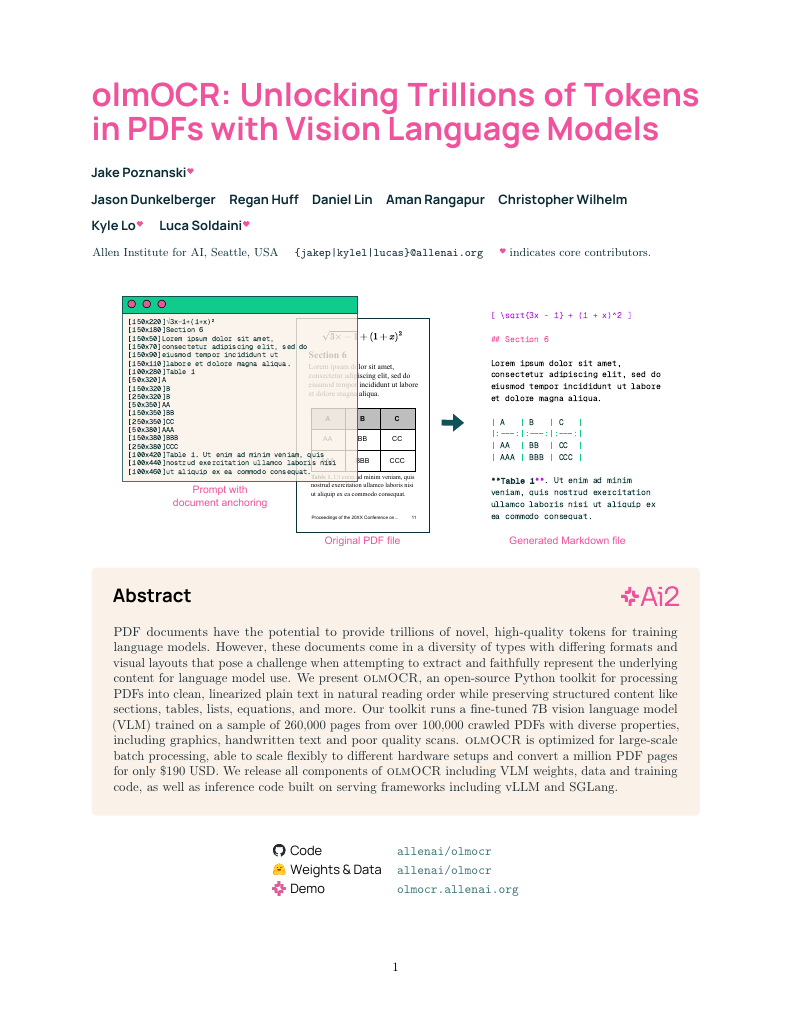

In [ ]:
import torch
import base64
import urllib.request

from io import BytesIO
from PIL import Image
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

from olmocr.data.renderpdf import render_pdf_to_base64png
from olmocr.prompts import build_finetuning_prompt
from olmocr.prompts.anchor import get_anchor_text

# Initialize the model
model = Qwen2VLForConditionalGeneration.from_pretrained("allenai/olmOCR-7B-0225-preview").eval()
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")
device = torch.device("cpu")
model.to(device)

# Grab a sample PDF

urllib.request.urlretrieve("https://olmocr.allenai.org/papers/olmocr.pdf", "./paper.pdf")
# Render page 1 to an image
image_base64 = render_pdf_to_base64png("./paper.pdf", 1, target_longest_image_dim=1024)

# Build the prompt, using document metadata
anchor_text = get_anchor_text("./paper.pdf", 1, pdf_engine="pdfreport", target_length=4000)
prompt = build_finetuning_prompt(anchor_text)

# Build the full prompt
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_base64}"}},
        ],
    }
]

# Apply the chat template and processor
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
main_image = Image.open(BytesIO(base64.b64decode(image_base64)))
display(main_image)

inputs = processor(
    text=[text],
    images=[main_image],
    padding=True,
    return_tensors="pt",
)

In [3]:
# Generate the output
output = model.generate(
    **inputs,
    temperature=0.8,
    max_new_tokens=500,
    num_return_sequences=1,
    do_sample=True,
)

# Decode the output
prompt_length = inputs["input_ids"].shape[1]
new_tokens = output[:, prompt_length:]
text_output = processor.tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

You can see some technical fields in the response, like `primary_language`, `is_rotation_valid`, `rotation_correction`, `is_table`, `is_diagram`:

In [4]:
import json

from IPython.display import Markdown, display


json_output = json.loads(text_output[0])

print(json_output.keys())

dict_keys(['primary_language', 'is_rotation_valid', 'rotation_correction', 'is_table', 'is_diagram', 'natural_text'])


`natural_text` contains generated markdown text. So, you can parse this text to get represented structured content:

In [5]:
display(Markdown(json_output["natural_text"]))

olmOCR: Unlocking Trillions of Tokens in PDFs with Vision Language Models

Jason Dunkelberger  Regan Huff  Daniel Lin  Aman Rangapur  Christopher Wilhelm

Kyle Lo  Luca Soldaini

Allen Institute for AI, Seattle, USA  {jakep|kylel|lucas}@allenai.org  ♡ indicates core contributors.

Abstract

PDF documents have the potential to provide trillions of novel, high-quality tokens for training language models. However, these documents come in a diversity of types with differing formats and visual layouts that pose a challenge when attempting to extract and faithfully represent the underlying content for language model use. We present olmOCR, an open-source Python toolkit for processing PDFs into clean, linearized plain text in natural reading order while preserving structured content like sections, tables, lists, equations, and more. Our toolkit runs a fine-tuned 7B vision language model (VLM) trained on a sample of 260,000 pages from over 100,000 crawled PDFs with diverse properties, including graphics, handwritten text and poor quality scans. olmOCR is optimized for large-scale batch processing, able to scale flexibly to different hardware setups and convert a million PDF pages for only $190 USD. We release all components of olmOCR including VLM weights, data and training code, as well as inference code built on serving frameworks including vLLM and SGLang.

Code  allenai/olmocr
Weights & Data  allenai/olmocr
Demo  olmocr.allenai.org

In [6]:
import gc


del model
gc.collect();

# Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

olmOCR is PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). [OpenVINO model conversion API](https://docs.openvino.ai/2025/openvino-workflow/model-preparation.html#convert-a-model-with-python-convert-model) should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.compile_model`. 

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).


### Compress model weights to 4-bit
[back to top ⬆️](#Table-of-contents:)
For reducing memory consumption, weights compression optimization can be applied using [NNCF](https://github.com/openvinotoolkit/nncf). 

<details>
    <summary><b>Click here for more details about weight compression</b></summary>
Weight compression aims to reduce the memory footprint of a model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs). LLMs and other models, which require extensive memory to store the weights during inference, can benefit from weight compression in the following ways:

* enabling the inference of exceptionally large models that cannot be accommodated in the memory of the device;

* improving the inference performance of the models by reducing the latency of the memory access when computing the operations with weights, for example, Linear layers.

[Neural Network Compression Framework (NNCF)](https://github.com/openvinotoolkit/nncf) provides 4-bit / 8-bit mixed weight quantization as a compression method primarily designed to optimize LLMs. The main difference between weights compression and full model quantization (post-training quantization) is that activations remain floating-point in the case of weights compression which leads to a better accuracy. Weight compression for LLMs provides a solid inference performance improvement which is on par with the performance of the full model quantization. In addition, weight compression is data-free and does not require a calibration dataset, making it easy to use.

`nncf.compress_weights` function can be used for performing weights compression. The function accepts an OpenVINO model and other compression parameters. Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality.

More details about weights compression, can be found in [OpenVINO documentation](https://docs.openvino.ai/2025/openvino-workflow/model-optimization-guide/weight-compression.html).
</details>

In [7]:
import ipywidgets as widgets

model_id = "allenai/olmOCR-7B-0225-preview"
base_model_path = Path(model_id.split("/")[-1])

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("olmocr-pdf-vlm.ipynb")

to_compress = widgets.Checkbox(value=True, description="Compress model")
to_compress

Checkbox(value=True, description='Compress model')

In [8]:
from cmd_helper import optimum_cli

model_path = base_model_path / ("INT4" if to_compress.value else "FP16")

if not model_path.exists():
    optimum_cli(model_id, model_path, additional_args={"weight-format": "int4" if to_compress.value else "fp16"})

## Prepare OpenVINO GenAI Inference Pipeline
[back to top ⬆️](#Table-of-contents:)

[OpenVINO™ GenAI](https://github.com/openvinotoolkit/openvino.genai) is a library with the most popular Generative AI model pipelines, optimized execution methods, and samples that run on top of highly performant [OpenVINO Runtime](https://github.com/openvinotoolkit/openvino).

This library is friendly to PC and laptop execution, and optimized for resource consumption. It requires no external dependencies to run generative models as it already includes all the core functionality (e.g. tokenization via openvino-tokenizers). OpenVINO™ GenAI is a flavor of OpenVINO™, aiming to simplify running inference of generative AI models. It hides the complexity of the generation process and minimizes the amount of code required.

Inference of visual language models can be implemented using OpenVINO GenAI `VLMPipeline` class. Similarly to `LLMPipeline`, that we discussed in this [notebook](https://openvinotoolkit.github.io/openvino_notebooks/?search=Create+an+LLM-powered+Chatbot+using+OpenVINO+Generate+API). It supports chat mode with preserving conversational history inside pipeline, that allows us effectively implements chatbot that supports conversation about provided images content.

### Select inference device
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from notebook_utils import device_widget

device = device_widget(default="AUTO")

device

### Load OpenVINO model
[back to top ⬆️](#Table-of-contents:)

For pipeline initialization we should provide path to model directory and inference device.

In [ ]:
import openvino_genai as ov_genai

pipe = ov_genai.VLMPipeline(model_path, device=device.value)

## Run OpenVINO GenAI model inference
[back to top ⬆️](#Table-of-contents:)

Now, when we have model and defined generation pipeline, we can run model inference.

For preparing input data, `VLMPipeline` use tokenizer and image processor inside, we just need to convert image to input OpenVINO tensor and provide question as string. 

In [11]:
import requests
from PIL import Image

import numpy as np
import openvino as ov


def load_image(image):
    image_data = np.array(image.getdata()).reshape(1, image.size[1], image.size[0], 3).astype(np.byte)
    return image, ov.Tensor(image_data)


image, image_tensor = load_image(main_image)

API is different from the original. `generate` method accepts prompt and image tensor.

In [12]:
output = pipe.generate(
    prompt=prompt,
    image=image_tensor,
    temperature=0.8,
    max_new_tokens=500,
    num_return_sequences=1,
    stop_strings="<|im_end|>",
    do_sample=True,
)

In [13]:
display(Markdown(json.loads(output.texts[0])["natural_text"]))

olmOCR: Unlocking Trillions of Tokens in PDFs with Vision Language Models

Jake Poznanski
Jason Dunkelberger  Regan Huff  Daniel Lin  Aman Rangapur  Christopher Wilhelm
Kyle Lo  Luca Soldaini

Allen Institute for AI, Seattle, USA  {jakep|kylel|lucas}@allenai.org  ♦ indicates core contributors.

Abstract

PDF documents have the potential to provide trillions of novel, high-quality tokens for training language models. However, these documents come in a diversity of types with differing formats and visual layouts that pose a challenge when attempting to extract and faithfully represent the underlying content for language model use. We present olmOCR, an open-source Python toolkit for processing PDFs into clean, linearized plain text in natural reading order while preserving structured content like sections, tables, lists, equations, and more. Our toolkit runs a fine-tuned 7B vision language model (VLM) trained on a sample of 260,000 pages from over 100,000 crawled PDFss with diverse properties, including graphics, handwritten text and poor quality scans. olmOCR is optimized for large-scale batch processing, able to scale flexibly to different hardware setups and convert a million PDF pages for only $190 USD. We release all components of olmOCR including VLM weights, data and training code, as well as inference code built on serving frameworks including vLLM and SGLang.

Code  allenai/olmocr
Weights & Data  allenai/olmocr
Demo  olmocr.allenai.org

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(pipe)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/